# Multiple polygons

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import lostinmsh as lsm

plt.rcParams.update({"font.size": 15})

## Define the polygon

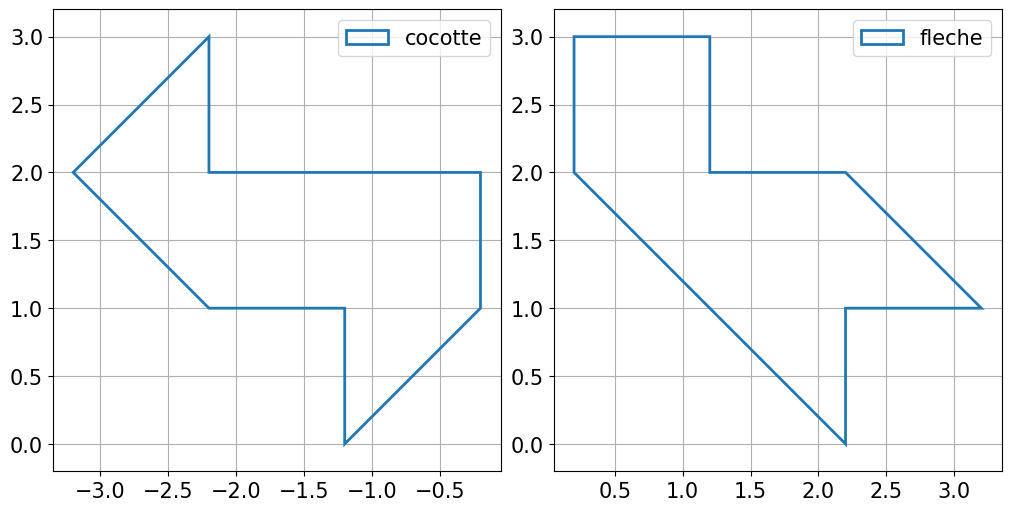

In [2]:
cocotte = np.array([[2, 0], [3, 1], [3, 2], [1, 2], [1, 3], [0, 2], [1, 1], [2, 1]])
fleche = np.array([[2, 0], [2, 1], [3, 1], [2, 2], [1, 2], [1, 3], [0, 3], [0, 2]])

polygons = [
    lsm.Polygon.from_vertices(cocotte - np.array([3.2, 0]), "cocotte"),
    lsm.Polygon.from_vertices(fleche + np.array([0.2, 0]), "fleche"),
]

fig, axs = plt.subplots(ncols=2, figsize=[10, 5], layout="constrained")
_ = lsm.plot_polygon(polygons[0], ax=axs[0])
_ = lsm.plot_polygon(polygons[1], ax=axs[1])

## Define the geometry

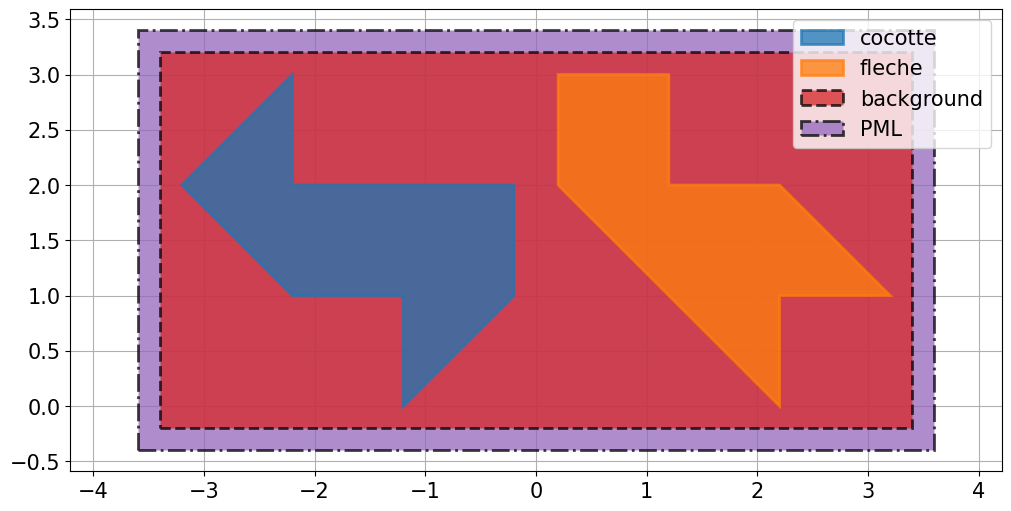

In [3]:
boundary = lsm.rectangular_boundary(polygons, 0.25, "background", 0.25, "PML")
geometry = lsm.Geometry.from_polygons(polygons, boundary)

fig, axs = plt.subplots(figsize=[10, 5], layout="constrained")
_ = lsm.plot_geometry(geometry, ax=axs)

## Mesh the geometry

In [4]:
lsm.mesh_unstructured(geometry, 0.2, lsm.GmshOptions(filename="mesh.msh"))

Info    : Increasing process stack size (8192 kB < 16 MB)


PurePosixPath('mesh.msh')

## Locally structured mesh the geometry

In [5]:
lsm.mesh_locally_structured(geometry, 0.2, lsm.GmshOptions(filename="mesh_lost.msh"))

PurePosixPath('mesh_lost.msh')

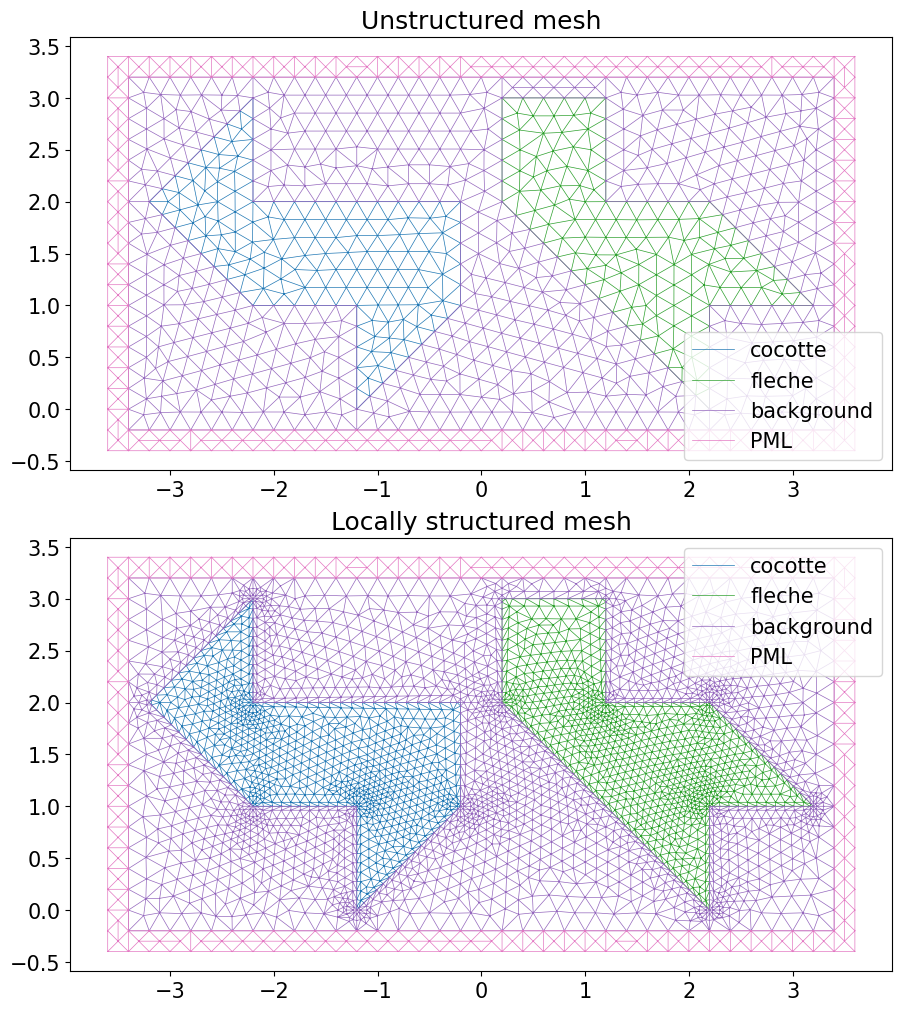

In [6]:
fig, axs = plt.subplots(nrows=2, figsize=[10, 10], layout="constrained")

axs[0].set_title("Unstructured mesh")
lsm.plot_mesh("mesh.msh", ax=axs[0])

axs[1].set_title("Locally structured mesh")
lsm.plot_mesh("mesh_lost.msh", ax=axs[1])